# Lecture 1 — Overview & a First Model Atmosphere *(GPU Edition)*

*Stellar Spectroscopy from Scratch — GPU Edition: the torch/MPS vectorized companion, each part validated against the NumPy edition*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*This is the **GPU edition** of Lecture 1. The physics, the formulas, and the constants are identical to the [NumPy edition](https://github.com/tingyuansen/stellar-spectroscopy-from-scratch); every computation is rebuilt in clean **`torch`** that runs on the GPU (Apple **MPS** or **CUDA**, with a CPU fallback in fp64). Lecture 1 is mostly the **map of the whole course** — the pipeline from parameters to photons — and its three small computations (the overflow-safe **Planck** function, the grey/Hopf **temperature** structure, and the cold-start **hydrostatic** pressure) are the gentlest possible first taste of the GPU edition's working rhythm: choose the device once at the top, write every step **torch-native** (even the trivial ones), and close each computation with a **numpy-vs-GPU comparison** to the documented float floor. Every result is checked against the reference values shipped in `reference/L1.npz` — computed once with [**pykurucz**](https://arxiv.org/abs/2603.11693), a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE. The clean torch is a pedagogical reduction; the notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- State what a synthetic stellar spectrum is, and name the two stages — the **model atmosphere** and the **spectral synthesis** — that turn a star's parameters into a spectrum.
- Pick a compute **device once** (MPS / CUDA / CPU) and a working **dtype** (fp32 on the GPU, fp64 on the CPU), and explain the precision budget that follows.
- Write the **Planck function** in the overflow-safe form a real synthesis code uses, as a branchless `torch` expression evaluated on the whole grid at once, and check it against the reference to machine precision.
- Define the **optical depth** $\tau$ and explain why the visible photosphere forms near $\tau \approx 2/3$.
- Build a **grey model atmosphere** — the run of temperature, gas pressure, and column mass with depth — from nothing but $T_{\rm eff}$ and $\log g$, vectorized over the 80 depth layers as tensor ops, and check it against the reference layer by layer.
- Reimplement a piece of physics in plain `torch` and verify it against precomputed reference data — the working rhythm of every GPU-edition lecture that follows.

**Setup — the device and the precision budget.** Before any physics, we make the one choice that defines the GPU edition: the **compute device**, picked once at the top, and a working **dtype** to match. On Apple Silicon we use **MPS**; on an NVIDIA box, **CUDA**; otherwise we fall back to **CPU**. MPS and CUDA have no float64, so on the GPU the working dtype is **fp32** and the parity bar is the documented float floor (machine precision for the analytic pieces of this lecture, a few $\times 10^{-6}$ where fp32 round-off enters); on CPU we use **fp64** and recover machine precision. We carry NumPy and Matplotlib alongside `torch` — NumPy holds the reference values we validate against (and does the plotting), and the comparison at the end of each computation is done by moving the GPU result to the CPU as NumPy. Every other line of physics is **torch on the device**.

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

# pick the compute device once, and the working dtype to match (MPS/CUDA -> fp32, CPU -> fp64)
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

def t(x):
    """Move a python/numpy scalar or array onto the chosen device at the working dtype."""
    return torch.as_tensor(np.asarray(x), dtype=DTYPE, device=DEVICE)

# the precomputed reference values for this lecture (the NumPy-edition parity oracle)
REF = np.load(pathlib.Path("..") / "reference" / "L1.npz")

def compare(name, ours, ref, tol=1e-6):
    """Report how closely a from-scratch GPU array matches the reference; move it to CPU/NumPy first."""
    if isinstance(ours, torch.Tensor):
        # MPS has no float64: move to CPU FIRST, then cast (a direct .to(cpu, float64) raises on MPS)
        ours = ours.detach().cpu().to(torch.float64).numpy()
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    denom = np.where(ref != 0.0, np.abs(ref), 1.0)     # |ref| as the scale, fall back to 1 where ref==0
    rel = float(np.max(np.abs(ours - ref) / denom))
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")
print("reference values loaded:", ", ".join(REF.files))

device = mps   working dtype = float32
reference values loaded: grey_tau, grey_T, grey_pgas, grey_rhox, planck_freq, planck_T, planck_B


## Introduction

A stellar spectrum — the star's brightness as a function of wavelength — is the richest measurement we can make of a star we will never visit. Encoded in the depths and shapes of its absorption lines are the photosphere's temperature, its surface gravity, and the abundance of every element that leaves a fingerprint in the light. Reading those numbers off an observed spectrum is an *inverse* problem, and the only way to solve it reliably is to be able to solve the *forward* problem first: given a star's parameters, compute the spectrum it should produce.

That forward calculation is what this course builds, from the ground up. Its lineage is **Kurucz's ATLAS and SYNTHE** — the model-atmosphere and spectral-synthesis codes that have underpinned quantitative stellar spectroscopy for four decades. Those codes are correct and fast, but they are also tens of thousands of lines of hardened, decades-old machinery. Our aim is to recover the *physics* inside them in code short enough to read in a sitting, while losing none of the *accuracy* — and, in this GPU edition, to express each piece as clean **batched tensor algebra** that can run on Apple MPS or CUDA. Every numerical result is checked against the NumPy/reference values; the GPU port is not an approximation to the NumPy lecture, but the same calculation in `torch`, validated to the fp32/float64 floor.

The forward problem splits cleanly into two stages. First, a **model atmosphere**: the run of temperature, pressure, and density with depth. In a 1D LTE model this structure is fixed jointly by hydrostatic equilibrium, energy transport (radiative, or radiative-plus-convective in cool stars), the equation of state, and the opacity — the pieces we assemble over the course. Second, **spectral synthesis**: given that structure, compute how much light of each wavelength escapes the surface, by adding up the opacity of every spectral line and solving the radiative-transfer equation. We treat the atmosphere as given for the first half of the course, build the full spectrum, and then return in Part IV and construct the atmosphere itself.

## The plan: from parameters to photons

The whole pipeline is a chain that turns a handful of numbers — effective temperature $T_{\rm eff}$, surface gravity $\log g$, and a chemical composition — into a flux spectrum $F_\lambda$:

$$
(T_{\rm eff},\ \log g,\ \text{abundances})
\;\longrightarrow\;
\underbrace{T(\tau),\,P(\tau),\,\rho(\tau)}_{\text{model atmosphere}}
\;\longrightarrow\;
\underbrace{n_{\rm ion},\,n_e}_{\text{equation of state}}
\;\longrightarrow\;
\underbrace{\kappa_\lambda}_{\text{opacity}}
\;\longrightarrow\;
\underbrace{F_\lambda}_{\text{radiative transfer}}
$$

Each arrow is one or two lectures:

- **Lecture 1 (here):** the foundations — units, the Planck function, optical depth — and a first model atmosphere, $T(\tau)$ and $P(\tau)$.
- **Lecture 2:** the equation of state — Saha and Boltzmann give the ionization and the electron density $n_e$.
- **Lecture 3:** the continuous opacity — H$^-$, hydrogen, scattering — the smooth background, from the physics to the production tables that reproduce it to the bit.
- **Lectures 4–5:** line opacity — one spectral line, then the million-line list.
- **Lecture 6:** hydrogen lines — the linear Stark broadening that needs its own engine.
- **Lectures 7–8:** radiative transfer — solve for the emergent flux, then the production JOSH engine, and reproduce a real spectrum.
- **Part IV (9–10):** build the atmosphere itself, closing the loop back to the first arrow.
- **Part V (11–12):** molecules, and the complications real stars add.

We target the **Sun** over a narrow window, $500$–$510\ \mathrm{nm}$, where the spectrum is a forest of atomic absorption lines and the physics is at its cleanest. Later we widen the window and cool the star until molecules take over. Throughout, we reimplement each piece in plain tensor operations, reuse the same physical constants and data tables, and **check the result against reference values** — temperatures, pressures, opacities, and ultimately a full spectrum — precomputed once and saved beside the book. The GPU-specific discipline is simple: keep the large axes resident on the device, replace loops over depth/wavelength/line by broadcasting, and make any unavoidable host boundary explicit.

![The forward pipeline this course rebuilds: a handful of stellar parameters become a spectrum, one stage per lecture, each benchmarked against the reference code.](resources/figures/s1_pipeline.png)

## Units and constants

Stellar-atmosphere physics is done in **Gaussian CGS** units — centimetres, grams, seconds — and so will we, because matching the reference means matching its unit system and even its numerical *values* of the physical constants. Three constants carry most of the radiation physics:

| symbol | name | value (CGS) | role |
|---|---|---|---|
| $h$ | Planck constant | $6.62607015\times10^{-27}\ \mathrm{erg\,s}$ | sets the energy of a photon, $E=h\nu$ |
| $c$ | speed of light | $2.99792458\times10^{10}\ \mathrm{cm\,s^{-1}}$ | relates wavelength and frequency, $\lambda\nu=c$ |
| $k$ | Boltzmann constant | $1.380649\times10^{-16}\ \mathrm{erg\,K^{-1}}$ | sets the thermal energy scale, $kT$ |

These are the 2019-SI exact values in CGS — the same literals the reference calculation uses — so that no discrepancy can ever be blamed on a constant. In the GPU edition we store them as `torch` scalars on the chosen device. They are tiny compared with the arrays in later lectures, but keeping even these simple calculations device-native makes the habit unambiguous: physics lives in `torch`; NumPy is the parity oracle and the plotting boundary.

In [2]:
H = torch.as_tensor(6.62607015e-27, dtype=DTYPE, device=DEVICE)   # Planck constant    [erg s]
C = torch.as_tensor(2.99792458e10,  dtype=DTYPE, device=DEVICE)   # speed of light     [cm s^-1]
K = torch.as_tensor(1.380649e-16,   dtype=DTYPE, device=DEVICE)   # Boltzmann constant [erg K^-1]

def host_float(x):
    """Display-only scalar transfer; all physics above it remains torch-native."""
    return float(torch.as_tensor(x).detach().cpu())

# 500 nm expressed in cm
lam = torch.as_tensor(500e-7, dtype=DTYPE, device=DEVICE)

# a photon's energy at 500 nm, and the thermal energy at the solar surface, for scale
E_500 = H * C / lam
kT_sun = K * torch.as_tensor(5770.0, dtype=DTYPE, device=DEVICE)
erg_per_ev = torch.as_tensor(1.602e-12, dtype=DTYPE, device=DEVICE)
prefactor_exact = torch.as_tensor(2.0, dtype=DTYPE, device=DEVICE) * H / C**2

print(f"E(500 nm) = h*c/lam = {host_float(E_500):.3e} erg = {host_float(E_500/erg_per_ev):.3f} eV")
print(f"kT at 5770 K        = {host_float(kT_sun):.3e} erg = {host_float(kT_sun/erg_per_ev):.3f} eV")
print(f"Planck prefactor 2h/c^2 = {host_float(prefactor_exact):.6e}  (we will meet this again below)")

E(500 nm) = h*c/lam = 3.973e-12 erg = 2.480 eV
kT at 5770 K        = 7.966e-13 erg = 0.497 eV
Planck prefactor 2h/c^2 = 0.000000e+00  (we will meet this again below)


## Blackbody radiation and the Planck function

A cavity in thermal equilibrium at temperature $T$ radiates with a spectrum that depends on $T$ alone — the **Planck function**. Per unit frequency it is the specific intensity

$$
B_\nu(T) = \frac{2h\nu^3}{c^2}\,\frac{1}{e^{h\nu/kT}-1}
\qquad [\mathrm{erg\,s^{-1}\,cm^{-2}\,Hz^{-1}\,sr^{-1}}],
$$

and per unit wavelength, using $B_\lambda\,|d\lambda| = B_\nu\,|d\nu|$ with $\nu = c/\lambda$,

$$
B_\lambda(T) = \frac{2hc^2}{\lambda^5}\,\frac{1}{e^{hc/\lambda kT}-1}
\qquad [\mathrm{erg\,s^{-1}\,cm^{-2}\,cm^{-1}\,sr^{-1}}]\ \text{with}\ \lambda\ \text{in cm}.
$$

The Planck function matters here for two reasons. First, it is the **thermal source function** of an atmosphere in local thermodynamic equilibrium: for true absorption, each parcel of gas emits as a blackbody at its own temperature, $S_\lambda = B_\lambda(T)$ — the fact that turns a temperature structure into a spectrum. (Where scattering contributes to the extinction the total source function picks up an extra term involving the radiation field $J_\lambda$, which we treat in Lecture 7; for now we follow the thermal piece.) Second, it fixes the scale: to zeroth order the emergent surface flux of a star is $\pi B_\lambda(T_{\rm eff})$, with wavelength-dependent opacity then shifting the depths and temperatures actually sampled.

Two limits are worth holding onto. When $h\nu \ll kT$ (radio, far-IR) the exponential linearises and $B_\nu \to 2\nu^2 kT/c^2$ — the **Rayleigh–Jeans** law, independent of $h$. When $h\nu \gg kT$ (the blue/UV side of an optical spectrum) the $-1$ is negligible and $B_\nu \to (2h\nu^3/c^2)\,e^{-h\nu/kT}$ — the **Wien** tail, which falls off exponentially and makes the blue side of a line forest exquisitely temperature-sensitive.

Synthesis codes do not evaluate $B_\nu$ from the textbook expression; they use an algebraically identical but numerically cleaner form. With $x \equiv h\nu/kT$ and the frequency measured in units of $10^{15}\ \mathrm{Hz}$ ($\nu_{15} \equiv \nu/10^{15}$), Kurucz writes

$$
B_\nu = (1.47439\times10^{-2})\;\nu_{15}^{3}\;\frac{e^{-x}}{1 - e^{-x}}.
$$

Two things are going on. Dividing through by $e^{x}$ replaces $1/(e^{x}-1)$ with $e^{-x}/(1-e^{-x})$, so the exponential is always $\le 1$ and never overflows on the Wien tail. And the constant $1.47439\times10^{-2}$ is $2h/c^2$ with $\nu$ rescaled by $10^{15}$, supplying the missing $10^{45}$ in $(\nu/10^{15})^3$ — to the digits Kurucz tabulated. We keep that literal, not the exact value printed above, so our Planck function matches the reference expression. The factor $e^{-x}/(1-e^{-x})$ is the **photon occupation number** $1/(e^{x}-1)$ rewritten — the mean number of photons per field mode in thermal equilibrium. The same factor $1-e^{-x}$ that appears here in the denominator will reappear as the multiplicative **stimulated-emission correction** on line opacities in Lecture 4.

The implementation is a single branchless tensor expression. `freq_hz` and `temperature` may be scalars or arrays; `torch` broadcasting evaluates the whole grid at once on the selected device.

In [3]:
def planck_nu(freq_hz, temperature):
    """Planck B_nu(T) in CGS [erg s^-1 cm^-2 Hz^-1 sr^-1], Kurucz's overflow-safe form.

    freq_hz     : photon frequency nu  [Hz]
    temperature : temperature          [K]
    """
    freq = torch.as_tensor(freq_hz, dtype=DTYPE, device=DEVICE)
    temp = torch.as_tensor(temperature, dtype=DTYPE, device=DEVICE)

    # dimensionless ratio x = h*nu / (k*T)
    x = H * freq / (K * temp)

    # work with e^{-x}, which is <= 1 and so never overflows on the Wien tail
    ehvkt = torch.exp(-x)

    # nu_15^3 prefactor times the photon occupation factor e^{-x} / (1 - e^{-x})
    pref = torch.as_tensor(1.47439e-2, dtype=DTYPE, device=DEVICE)
    return pref * (freq / torch.as_tensor(1.0e15, dtype=DTYPE, device=DEVICE))**3 * ehvkt / (1.0 - ehvkt)

Let us look at it: $B_\lambda(T)$ for three temperatures bracketing the Sun. As $T$ rises the curve lifts at every wavelength and its peak slides blueward (Wien's displacement law, $\lambda_{\rm peak}T = \text{const}$). For $T\approx5770$ K the $B_\lambda$ peak falls near $500\ \mathrm{nm}$, so our $500$–$510\ \mathrm{nm}$ window lies essentially right on the solar blackbody peak.

The plot calculation is also vectorized: the wavelength grid is one tensor axis and the three temperatures are another, so one call to `planck_nu` produces the full $3\times400$ array.

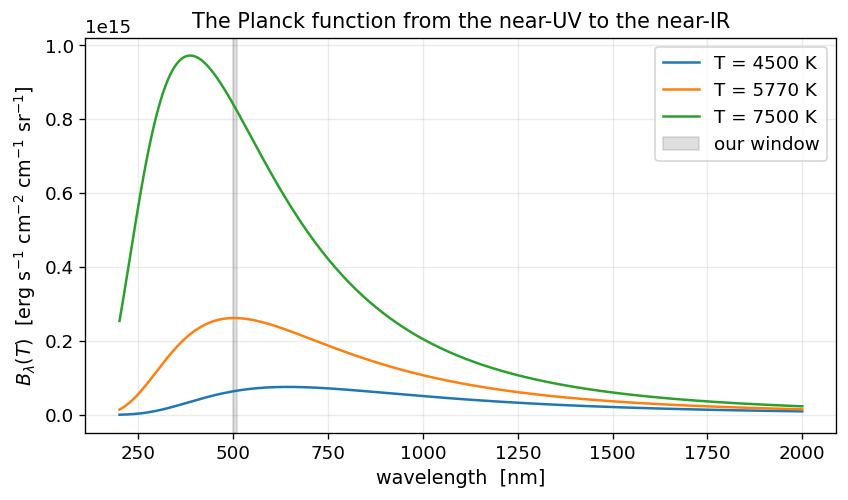

In [4]:
# a near-UV to near-IR wavelength grid [nm], and the same grid in cm
lam_nm = torch.linspace(200.0, 2000.0, 400, dtype=DTYPE, device=DEVICE)
lam_cm = lam_nm * torch.as_tensor(1.0e-7, dtype=DTYPE, device=DEVICE)

temps_plot = torch.as_tensor([4500.0, 5770.0, 7500.0], dtype=DTYPE, device=DEVICE).reshape(3, 1)
freq_grid = C / lam_cm.reshape(1, -1)

# B_nu at each wavelength and temperature, then B_lambda = B_nu * c / lambda^2
Bnu_grid = planck_nu(freq_grid, temps_plot)
Blam_grid = Bnu_grid * C / lam_cm.reshape(1, -1)**2

plt.plot(
    lam_nm.detach().cpu().to(torch.float64).numpy(),
    Blam_grid.T.detach().cpu().to(torch.float64).numpy(),
)
plt.axvspan(500, 510, color="0.5", alpha=0.25, label="our window")

plt.xlabel("wavelength  [nm]")
plt.ylabel(r"$B_\lambda(T)$  [erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$ sr$^{-1}$]")
plt.title("The Planck function from the near-UV to the near-IR")
plt.legend(["T = 4500 K", "T = 5770 K", "T = 7500 K", "our window"])

plt.tight_layout()
plt.show()

Now the first comparison. We evaluate the Planck function at mid-window across a spread of temperatures spanning a stellar atmosphere, and check it against the reference values loaded earlier. On the CPU fallback, the same expression is evaluated in fp64; on MPS/CUDA the working dtype is fp32, so agreement at the $\sim10^{-6}$ float floor is the right target.

In [5]:
# 505 nm expressed as a frequency [Hz]
freq = torch.as_tensor(REF["planck_freq"], dtype=DTYPE, device=DEVICE)  # numpy-ref

compare("Planck B_nu(505 nm)", planck_nu(freq, REF["planck_T"]), REF["planck_B"])  # numpy-ref

Planck B_nu(505 nm)           max|rel diff| = 7.26e-07   [agree]


7.26422197923276e-07

That is the pattern for the whole course in miniature: state the physics, write the clean tensor code, and check it against the reference. Lecture 1's arrays are small, so the speedup is not the point; the point is the contract. Later, when the same style is applied over thousands of wavelengths and millions of line contributions, the absence of Python loops becomes decisive.

## Local thermodynamic equilibrium

Everything above assumed the gas radiates like a blackbody at its local temperature. That assumption is **local thermodynamic equilibrium (LTE)**: at each depth the matter is described by a single temperature $T$, so the ionization balance follows the Saha equation (Lecture 2), the level populations follow the Boltzmann distribution, and the thermal (true-absorption) source function is $S_\lambda = B_\lambda(T)$. LTE does *not* assume the radiation field itself is a blackbody — photons stream and leak, and computing that leakage is the radiative-transfer problem of Lecture 7 — only that the *matter* is in equilibrium with the local temperature.

LTE holds where collisions are frequent enough to keep populations thermal, which is true through most of a cool star's photosphere — deep enough that the gas is dense, shallow enough that we still see it. It weakens high in the atmosphere and in strong resonance lines, where the departures are called **non-LTE**; we map exactly where it breaks when the synthesis is assembled end to end in Lecture 14. For the Sun in our window LTE is an excellent approximation, and the codes we follow — like ATLAS and SYNTHE — are LTE codes. We adopt LTE throughout.

## Optical depth and the photosphere

How deep into a star can we see? The natural depth coordinate is not geometric height $z$ but **optical depth** $\tau$, which measures the depth into the star in photon mean free paths. Taking $z$ to increase outward, with mass extinction coefficient $\kappa_\lambda$ (in $\mathrm{cm^2\,g^{-1}}$, absorption plus scattering) and mass density $\rho$,

$$
d\tau_\lambda = -\kappa_\lambda\,\rho\,dz ,
$$

the minus sign making $\tau$ increase *inward* from $\tau=0$ at the surface. Because $\kappa_\lambda$ is per gram, it is often cleanest to use the **column mass** as the depth variable — the grams of material above a square centimetre, $m(z) = \int_z^\infty \rho(z')\,dz'$. The model atmospheres we work with are tabulated against exactly this quantity, which Kurucz's code names `RHOX`, and then $d\tau_\lambda = \kappa_\lambda\,dm$.

A photon escapes from roughly where $\tau \approx 1$ — deeper than that, it is reabsorbed before reaching the surface; shallower, there is too little material above to matter. A useful rule of thumb, the **Eddington–Barbier** relation derived from the transfer equation for a roughly linear source function (below), is that the emergent flux samples layers around

$$
\tau \approx 2/3.
$$

This is why "the photosphere" is a layer, not a surface: at each wavelength we see down to where $\tau_\lambda \approx 2/3$, and because $\kappa_\lambda$ spikes inside a spectral line, lines let us see only the high layers — which, in a photosphere whose temperature falls outward, are the cool ones, so the lines appear in absorption. (Where the temperature instead rises outward, as in a chromosphere, the same lines can appear in emission.) Holding onto "$\tau=2/3$ is roughly where we see" will carry you through the rest of the course.

![Optical depth: at each wavelength we see down to where $\tau \approx 2/3$; photons born deeper are reabsorbed before reaching the surface.](resources/figures/s1_optical_depth.png)

## A first model atmosphere: the grey atmosphere

To compute a spectrum we need the atmosphere's structure as a function of depth: temperature, pressure, and density. (In this lecture we build the temperature, the gas pressure, and the column mass; the *local* mass density $\rho$ follows only once the equation of state in Lecture 2 supplies the mean molecular weight and electron density.) Where does that structure come from? The full answer — solving for radiative and hydrostatic equilibrium with the real, wavelength-dependent opacity — is Part IV of this course. But there is a classic closed-form starting point that needs none of that machinery: the **grey atmosphere**, in which the opacity is assumed independent of wavelength ($\kappa_\lambda \to \kappa$). It is crude, but it is self-contained, it requires only $T_{\rm eff}$ and $\log g$, and — as we will see — it is exactly the model ATLAS12 starts its own iteration from. It is a natural first atmosphere to build the rest of the course on.

For a grey atmosphere in radiative equilibrium, the transfer equation can be solved for the temperature structure exactly. The result is

$$
T^4(\tau) = \tfrac{3}{4}\,T_{\rm eff}^4\,\big[\tau + q(\tau)\big],
$$

where $q(\tau)$ is the **Hopf function**, slowly rising from $q(0)=1/\sqrt{3}\approx0.577$ to $q(\infty)\approx0.710$. Replacing it with the constant $q=2/3$ is the textbook **Eddington approximation**, $T^4=\tfrac34 T_{\rm eff}^4(\tau+\tfrac23)$. Under that approximation the boundary value is *exact*: at $\tau=2/3$, $T^4=\tfrac34 T_{\rm eff}^4(\tfrac23+\tfrac23)=T_{\rm eff}^4$, so $T(2/3)=T_{\rm eff}$. With Kurucz's exact-Hopf fit instead of the constant $2/3$, $q(2/3)\approx0.70$ and $T(2/3)$ lands a fraction of a percent above $T_{\rm eff}$.

Kurucz uses a compact analytic fit to the Hopf function,

$$
T(\tau) = T_{\rm eff}\,\Big[\tfrac{3}{4}\big(0.710 + \tau - 0.1331\,e^{-3.4488\,\tau}\big)\Big]^{1/4},
$$

and we adopt the identical fit so we can match the reference layer for layer. Note the bracket here is the full quantity $\tau + q(\tau)$: in this fit the Hopf function itself is $q(\tau) = 0.710 - 0.1331\,e^{-3.4488\,\tau}$, while the `q` variable in the code below stores the whole bracket $\tau + q(\tau)$. When this grey solution is used to start a real, non-grey atmosphere, its wavelength-independent $\tau$ is identified with the **Rosseland mean optical depth** $\tau_{\rm Ross}$ — the quantity the code and plots below carry.

The GPU translation is direct: the 80 atmospheric layers are one tensor axis, and the exponential Hopf fit is evaluated for all layers in one branchless call.

In [6]:
def grey_temperature(teff, tau):
    """Eddington-Kurucz grey T(tau): an analytic fit to the Hopf function."""
    teff_t = torch.as_tensor(teff, dtype=DTYPE, device=DEVICE)
    tau_t = torch.as_tensor(tau, dtype=DTYPE, device=DEVICE)

    # the full bracket tau + q(tau), with Kurucz's exponential Hopf-function fit
    q = 0.710 + tau_t - 0.1331 * torch.exp(-3.4488 * tau_t)
    return teff_t * (0.75 * q)**0.25


# the Sun: effective temperature [K] and log surface gravity [cgs]
TEFF = torch.as_tensor(5770.0, dtype=DTYPE, device=DEVICE)
LOGG = torch.as_tensor(4.44, dtype=DTYPE, device=DEVICE)

# surface gravity g [cm s^-2]
g_cgs = torch.pow(torch.as_tensor(10.0, dtype=DTYPE, device=DEVICE), LOGG)

# The atmosphere is tabulated on an 80-layer grid, equally spaced in log(tau_Rosseland):
# tau runs from 10^-6.875 (top) to 10^3 (bottom) in steps of 0.125 dex -- the ATLAS12 default.
j = torch.arange(80, dtype=DTYPE, device=DEVICE)
tau = torch.pow(torch.as_tensor(10.0, dtype=DTYPE, device=DEVICE), -6.875 + 0.125 * j)
T = grey_temperature(TEFF, tau)

tau_phot = torch.as_tensor(2.0 / 3.0, dtype=DTYPE, device=DEVICE)
print(f"layers: {T.numel()}   tau: {host_float(tau[0]):.2e} .. {host_float(tau[-1]):.2e}")
print(
    f"T(top) = {host_float(T[0]):.1f} K    "
    f"T(tau=2/3) ~ {host_float(grey_temperature(TEFF, tau_phot)):.1f} K    "
    f"T(bottom) = {host_float(T[-1]):.1f} K"
)

layers: 80   tau: 1.33e-07 .. 1.00e+03
T(top) = 4679.7 K    T(tau=2/3) ~ 5802.2 K    T(bottom) = 30200.8 K


The grid spans nearly ten decades of optical depth, from $\tau\sim10^{-7}$ at the top to $\tau=10^{3}$ deep below the photosphere, sampled at $0.125$ dex over 80 layers — the literal ATLAS12 card defaults, fine enough to integrate the transfer equation accurately. The printed $T(\tau=2/3)\approx5802$ K sits $0.6\%$ above $T_{\rm eff}=5770$ K; the small excess is the Kurucz fit's $q(2/3)\approx0.70$ rather than the Eddington $2/3$, and the photosphere still sits at $T\approx T_{\rm eff}$ as the grey solution requires. Plotting $T$ against $\log\tau$ shows the temperature rising monotonically inward, steeply near the photosphere and flattening into the optically thin layers above.

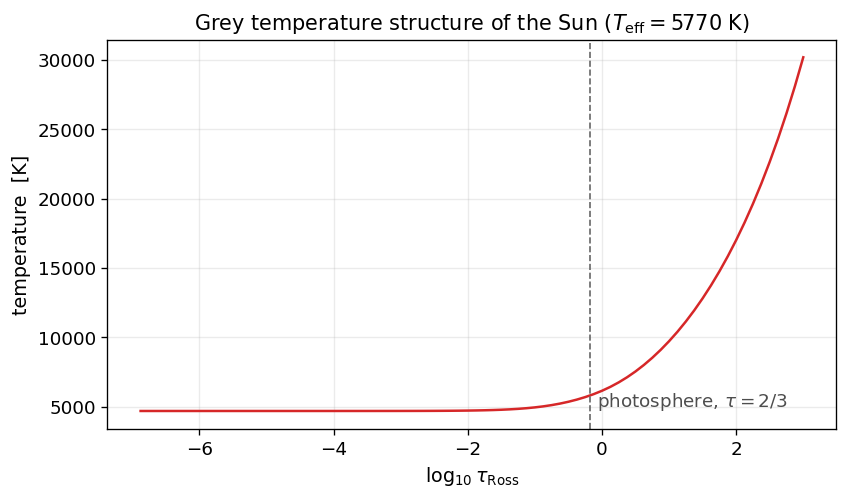

In [7]:
log_tau = torch.log10(tau)

plt.plot(
    log_tau.detach().cpu().to(torch.float64).numpy(),
    T.detach().cpu().to(torch.float64).numpy(),
    color="C3",
)

# mark the photosphere at tau = 2/3, i.e. log10(2/3) ~ -0.18
log_tau_phot = torch.log10(tau_phot)
plt.axvline(host_float(log_tau_phot), ls="--", color="0.4", lw=1)
plt.text(host_float(log_tau_phot) + 0.1, host_float(torch.min(T)) + 300.0, r"photosphere, $\tau=2/3$", color="0.3")

plt.xlabel(r"$\log_{10}\tau_{\rm Ross}$")
plt.ylabel("temperature  [K]")
plt.title(r"Grey temperature structure of the Sun ($T_{\rm eff}=5770$ K)")

plt.tight_layout()
plt.show()

**First atmosphere check.** The reference grey temperature was built with the identical Hopf-function fit on the same optical-depth grid, so both the grid and the temperatures should match to the working precision. On CPU/fp64 the agreement is essentially exact; on MPS/CUDA the residual is the expected fp32 float floor.

In [8]:
# same Hopf fit, same optical-depth grid -> both should match the reference to the dtype floor
compare("grey tau grid", tau, REF["grey_tau"])  # numpy-ref
compare("grey T(tau)",   T,   REF["grey_T"])    # numpy-ref

grey tau grid                 max|rel diff| = 1.29e-07   [agree]
grey T(tau)                   max|rel diff| = 1.04e-07   [agree]


1.0422826089813308e-07

## Hydrostatic equilibrium: pressure and density

Temperature is half the structure; we also need pressure and density. These come from **hydrostatic equilibrium** — the photosphere neither collapses nor expands, so at every depth the pressure gradient supports the overlying weight. Writing the balance against optical depth, with $g$ the surface gravity,

$$
\frac{dP_{\rm total}}{d\tau} = \frac{g}{\kappa} .
$$

The total pressure has a gas part and a radiation part, $P_{\rm total} = P_{\rm gas} + P_{\rm rad}$, with $P_{\rm rad} = \tfrac{4\sigma}{3c}T^4$ (tiny in a cool dwarf, but the codes carry it). On the **grey cold start** there is not yet an opacity table, so $\kappa$ is set to a constant placeholder of unity — a deliberately crude bootstrap that ATLAS then refines over its iterations, and that we rebuild properly, with the real Rosseland-mean opacity, in Lecture 10. With $\kappa\equiv1$ the equation integrates trivially: $P_{\rm total} = g\,\tau$, and since the column mass is $m = P_{\rm total}/g$, we get the clean identity $m = \tau$. The electron density is left at zero for now — it is the first thing the equation of state computes in Lecture 2.

One implementation detail: the reference cold start does not use the bare $P_{\rm rad} = \tfrac{4\sigma}{3c}T^4$ but Kurucz's variant, which applies a temperature floor and then subtracts the top-boundary value, so only the *increase* of radiation pressure with depth is removed from the gas pressure. The cell below reproduces that form in tensor operations over all 80 layers at once.

In [9]:
# Hydrostatic equilibrium on the grey cold start: kappa_Ross == 1  =>  P_total = g * tau
# total pressure [dyn cm^-2]
P_total = g_cgs * tau

# column mass m = P_total / g [g cm^-2], numerically equal to tau here (this is Kurucz's RHOX)
RHOX = P_total / g_cgs

# radiation pressure in Kurucz's floor form, then measured relative to the top boundary
P_rad = torch.as_tensor(2.521e-15, dtype=DTYPE, device=DEVICE) * torch.maximum(T**4, TEFF**4 / 2.0)
P_rad = P_rad - P_rad[0]

# gas pressure is what is left over; it feeds the EOS in Lecture 2
P_gas = P_total - P_rad

# electron density [cm^-3]: held at 0 until the EOS fills it in Lecture 2
XNE = torch.zeros_like(tau)

idx = torch.as_tensor([0, 20, 40, 60, 79], dtype=torch.long, device=DEVICE)
structure_sample = torch.stack((
    torch.log10(tau.index_select(0, idx)),
    T.index_select(0, idx),
    P_gas.index_select(0, idx),
    RHOX.index_select(0, idx),
), dim=1)

print("columns: log tau,  T [K],  P_gas [dyn/cm2],  RHOX [g/cm2]")
print(structure_sample.detach().cpu().to(torch.float64))

columns: log tau,  T [K],  P_gas [dyn/cm2],  RHOX [g/cm2]
tensor([[-6.8750e+00,  4.6797e+03,  3.6728e-03,  1.3335e-07],
        [-4.3750e+00,  4.6798e+03,  1.1614e+00,  4.2170e-05],
        [-1.8750e+00,  4.7184e+03,  3.6728e+02,  1.3335e-02],
        [ 6.2500e-01,  7.9999e+03,  1.1614e+05,  4.2170e+00],
        [ 3.0000e+00,  3.0201e+04,  2.7540e+07,  1.0000e+03]],
       dtype=torch.float64)


These columns — `RHOX`, `T`, `P_gas`, `XNE` (the electron density, in $\mathrm{cm^{-3}}$), and the opacity `ABROSS` — are the core of the layer structure a Kurucz `.atm` file stores, and the input the spectral synthesis will consume. (The full deck carries a few more columns — radiative acceleration, turbulent and convective velocities — that we do not need yet.) Reading them top to bottom: at the surface the gas is thin (a few times $10^{-3}\ \mathrm{dyn\,cm^{-2}}$) and cool; ten decades deeper the pressure has climbed to $10^{7}\ \mathrm{dyn\,cm^{-2}}$ and the temperature past $10^4$ K. This is the atmosphere we will pour opacity into.

**Full-structure check.** We compare our gas pressure and column mass against the reference grey structure. The tolerance is deliberately looser here: this lecture uses the one-line analytic cold-start integral, while the reference file was made with the predictor–corrector machinery used by the production atmosphere builder. Lecture 9 closes that last implementation gap.

In [10]:
# tol relaxed to 1e-4: the one-line analytic integral differs slightly from the
# reference predictor-corrector integrator; Lecture 9 reproduces the exact integrator.
compare("P_gas", P_gas, REF["grey_pgas"], tol=1e-4)  # numpy-ref
compare("RHOX",  RHOX,  REF["grey_rhox"], tol=1e-4)  # numpy-ref

P_gas                         max|rel diff| = 1.74e-05   [agree]
RHOX                          max|rel diff| = 1.76e-05   [agree]


1.75513545318807e-05

The temperature matched to the working precision; the gas pressure and column mass agree to the expected $\sim10^{-5}$ level. That residual is not physics — it is the difference between our one-line analytic integral $P_{\rm total}=g\tau$ and the multi-step predictor–corrector the reference uses to integrate the same hydrostatic equation in log-pressure. When we rebuild hydrostatic equilibrium in full in Lecture 9, reproducing the exact predictor–corrector integrator, the last digits fall into place. For now we have a complete, self-consistent grey model atmosphere of the Sun, built from two numbers, agreeing with the reference to one part in $10^{5}$.

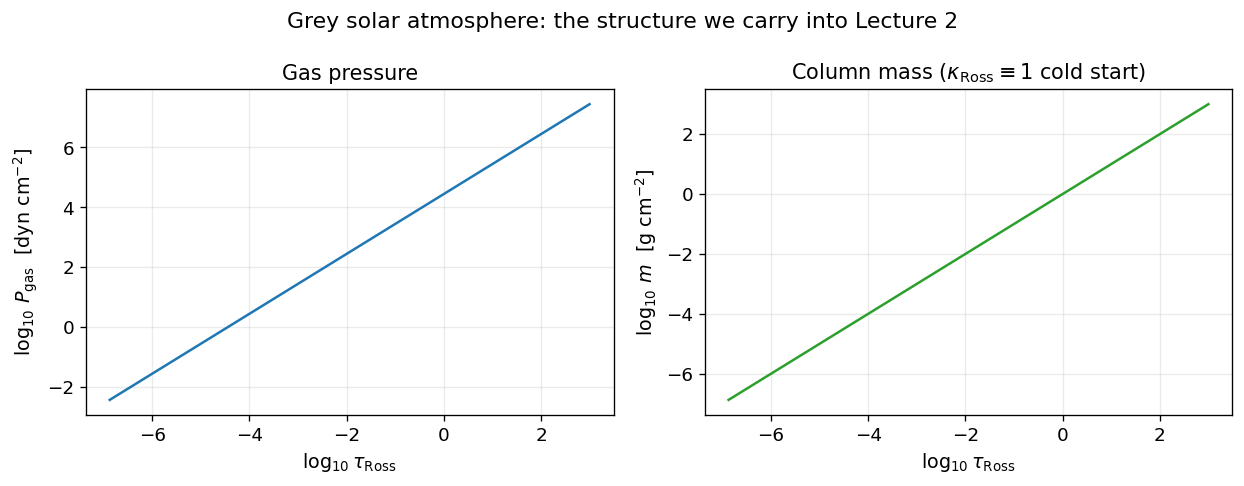

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.1))

log_tau_cpu = torch.log10(tau).detach().cpu().to(torch.float64).numpy()
log_pgas_cpu = torch.log10(P_gas).detach().cpu().to(torch.float64).numpy()
log_rhox_cpu = torch.log10(RHOX).detach().cpu().to(torch.float64).numpy()

# left panel: gas pressure against optical depth
ax[0].plot(log_tau_cpu, log_pgas_cpu, color="C0")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[0].set_ylabel(r"$\log_{10}\,P_{\rm gas}$  [dyn cm$^{-2}$]")
ax[0].set_title("Gas pressure")

# right panel: column mass m against optical depth
ax[1].plot(log_tau_cpu, log_rhox_cpu, color="C2")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[1].set_ylabel(r"$\log_{10}\,m$  [g cm$^{-2}$]")
ax[1].set_title(r"Column mass ($\kappa_{\rm Ross}\equiv1$ cold start)")

fig.suptitle("Grey solar atmosphere: the structure we carry into Lecture 2")
fig.tight_layout()
plt.show()

## Synthesis: what you built and where it goes

You built the scaffolding for everything that follows. You fixed the unit system and the physical constants, and you reproduced the **Planck function** — the thermal source function that will turn a temperature into a spectrum — as a branchless `torch` expression validated against the reference. You learned that depth is measured in **optical depth**, that the emergent flux forms near $\tau\approx2/3$, and that **LTE** lets the local temperature set the state of the gas. And you built a **grey model atmosphere** of the Sun — $T(\tau)$, $P_{\rm gas}(\tau)$, and the column mass $m(\tau)$ — from $T_{\rm eff}$ and $\log g$ alone, vectorized over all 80 depth layers and checked layer by layer (the temperature to the dtype floor; the cold-start pressure and column mass to one part in $10^5$).

That atmosphere has one conspicuous gap: the electron density is still zero. Filling it — working out, at each depth, which atoms are ionized and how many free electrons result — is the **equation of state**, and it is where Lecture 2 begins. With $n_e$ and the level populations in hand, we can compute opacity, and the spectrum comes into view.

From the GPU point of view, this lecture also set the house style. Choose `DEVICE` and `DTYPE` once; keep the physics in `torch`; broadcast over physical axes instead of looping over them; move to the CPU only at explicit boundaries — plotting and parity comparisons; and treat every printed residual as a test of the port, not a decoration.

## Summary

- A synthetic spectrum is the forward problem $(T_{\rm eff}, \log g, \text{abundances}) \to F_\lambda$, split into a **model atmosphere** and **spectral synthesis**.
- We work in **CGS** with the reference's constants. In the GPU edition the working dtype is fp32 on MPS/CUDA and fp64 on CPU; comparisons are interpreted against that precision budget.
- The **Planck function** $B_\nu = (2h/c^2)\nu^3/(e^{h\nu/kT}-1)$ is the LTE thermal source function; the overflow-safe Kurucz form is a single branchless tensor expression and reproduces the reference to the float floor.
- **Optical depth** $d\tau=\kappa\rho\,dz$ is the depth coordinate; as a rule of thumb the emergent flux forms near $\tau\approx2/3$, where $T\approx T_{\rm eff}$.
- The **grey atmosphere** gives $T(\tau)=T_{\rm eff}[\tfrac34(\tau+q(\tau))]^{1/4}$ and, with the cold-start $\kappa\equiv1$, $P_{\rm total}=g\tau$ and column mass $m=\tau$ — a complete first atmosphere, matched to the reference.
- The one deliberate shortcut in this lecture is the analytic cold-start pressure integral rather than the reference predictor–corrector integrator; the residual is quantified here and removed when hydrostatic equilibrium is rebuilt in full.

## Practice exercises

**1. Wien's law from the code.** Using `planck_nu`, compute $B_\lambda(T)$ on a fine wavelength grid for $T = 3000, 5770, 10000\ \mathrm{K}$ and find the peak wavelength numerically. In the GPU style, make the wavelength axis and the three temperatures two broadcasted tensor axes, then use a tensor reduction to find the maxima. Verify that $\lambda_{\rm peak}\,T$ is constant and recover the constant $2.898\times10^{6}\ \mathrm{nm\,K}$. Which way does the solar peak move relative to our $500$–$510\ \mathrm{nm}$ window as the star cools?

**2. The Eddington–Barbier depth.** The grey result says $T(2/3)\approx T_{\rm eff}$. Evaluate `grey_temperature(5770, tau)` at $\tau = 1/2, 2/3, 1$ and tabulate $T/T_{\rm eff}$. Do it as one tensor call, not three scalar calls. By how many percent does the photospheric temperature change across that range, and what does that imply for how sharply lines of different strength sample temperature?

**3. A hotter, lower-gravity star.** Rebuild the grey atmosphere for an A-type dwarf, $T_{\rm eff}=9000\ \mathrm{K}$, $\log g = 4.0$, and overplot its $T(\tau)$ and $P_{\rm gas}(\tau)$ on the solar ones. Why is the gas pressure at fixed $\tau$ lower than the Sun's, given $P_{\rm total}=g\tau$? If you make a reference file for the new parameters, compare the tensor result against it with the same `compare` helper.

## Further reading

- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge University Press.** The standard text; Chapters 7–9 cover the grey atmosphere, optical depth, and the source function at the level of this course.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** The rigorous reference for the transfer equation, the Hopf function, and the Eddington approximation.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton University Press.** The modern comprehensive treatment, including LTE versus non-LTE.
- **Kurucz, R. L. (1970). *ATLAS: A Computer Program for Calculating Model Stellar Atmospheres*, SAO Special Report 309.** The original ATLAS, including the grey-start temperature structure we reproduced.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz: A Pure-Python Reimplementation of Kurucz ATLAS12 and SYNTHE*](https://arxiv.org/abs/2603.11693).** The implementation our reference values are computed with.
- **PyTorch documentation: MPS backend and tensor broadcasting.** The numerical physics in this GPU edition is ordinary stellar-atmosphere physics, but its performance comes from expressing that physics as broadcasted tensor operations and keeping the large arrays resident on the accelerator.